### EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering
#### Bandara W.D.A.C. - 230082G

In [1]:
# imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

##### Q1. Intensity tranformation on 'emma' 

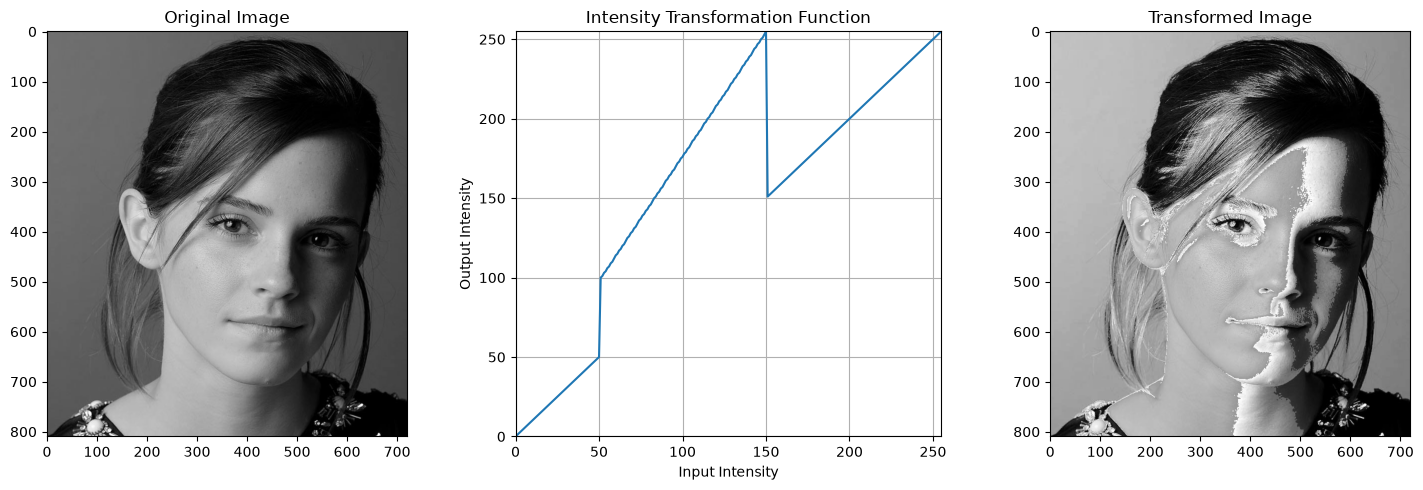

In [18]:
img_emma = cv.imread('./images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert img_emma is not None

def intensity_transform(im, breakpoints):
    tf = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x_start, y_start = breakpoints[i]
        x_end, y_end = breakpoints[i + 1]
        x = np.arange(x_start, x_end + 1)
        tf[x] = np.linspace(y_start, y_end, num=len(x)).astype('uint8')
    return cv.LUT(im, tf), tf

bp = np.array([(0, 0), (50, 50), (51, 100), (150, 255), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

According to the plot and images above, a certain range of intensities has been brightened. Also the discontinuities in the transformation funtion create sudden intensity jumps. 

We can adjust the transformation function to achieve much more visually pleasing results as follows.

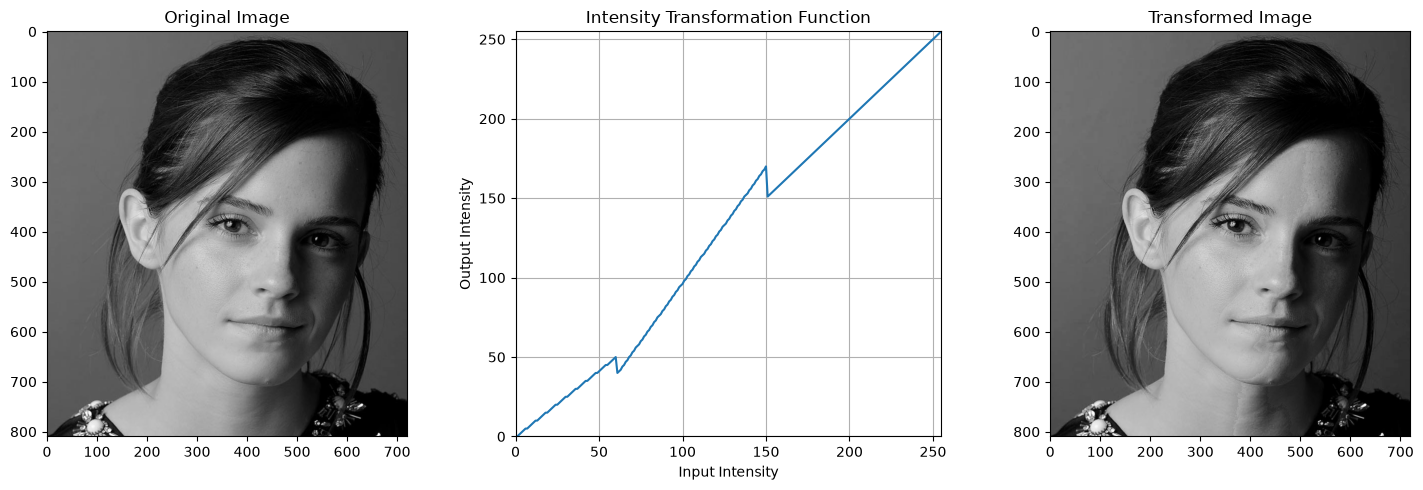

In [19]:
bp = np.array([(0, 0), (60, 50), (61, 40), (150, 170), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

##### Q2. Intensity tranformations on 'brain' 

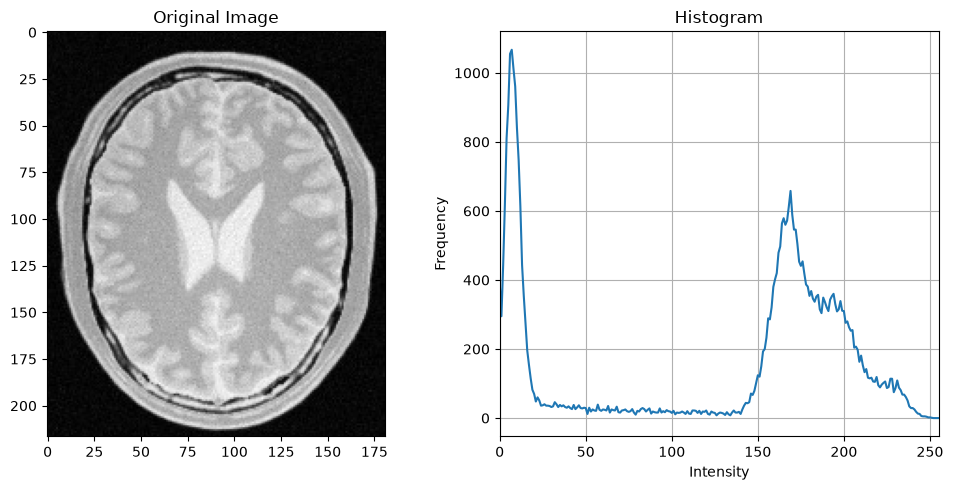

In [27]:
img_brain = cv.imread("./images/brain.jpeg", cv.IMREAD_GRAYSCALE)
assert img_brain is not None

hist = cv.calcHist([img_brain], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_brain, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(hist)
ax[1].set_title('Histogram')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim([0, 255])
ax[1].grid()
plt.tight_layout()
plt.show()

**Extracting white matter**

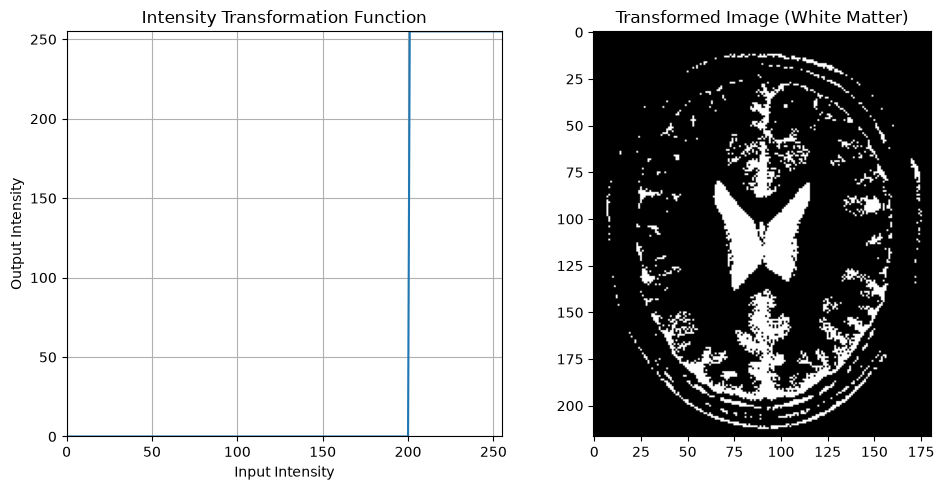

In [30]:
bp = np.array([(0, 0), (200, 0), (201, 255), (255, 255)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].set_ylim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()

**Extracting gray matter**

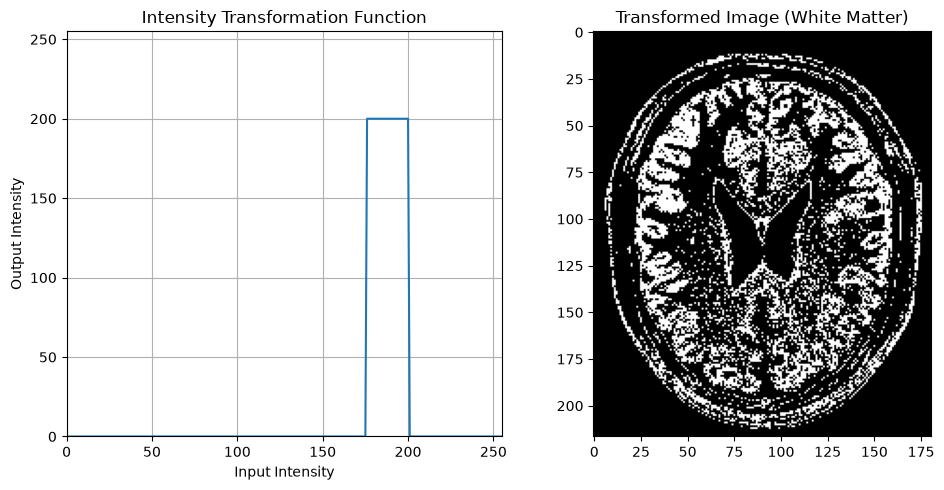

In [32]:
bp = np.array([(0, 0), (175, 0), (176, 200), (200, 200), (201, 0), (255, 0)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].set_ylim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()